# Prototype get gfw sar data

In [20]:
# gfw_s2_vessel_detections_min.py
from google.cloud import bigquery
import pandas as pd
import os 
import gfwapiclient as gfw
import matplotlib.pyplot as plt

In [21]:
year = 2024
temporal_granularity = 'DAILY'

start_date= f"{str(year)}-01-01"
end_date= f"{str(year)}-02-29" 
spatial_resolution= "HIGH" # LOW or MEDIUM or HIGH

product_name = "public-global-fishing-effort:latest"

#lat_name = 'lat'
#lon_name = 'lon'
lat_min = 45.4698
lat_max = 45.8078
lon_min = 13.141159647873394
lon_max = 13.8238

In [ ]:
from google.cloud import bigquery
from google.oauth2 import service_account

KEY_PATH = "../gcp_bigquery_key.json"
creds = service_account.Credentials.from_service_account_file(KEY_PATH)

# Legge direttamente dal file il project_id corretto
PROJECT_ID = creds.project_id
print("Project ID:", PROJECT_ID)

client = bigquery.Client(project=PROJECT_ID, credentials=creds, location="US")

for row in client.query("SELECT 1 AS test").result():
    print(row.test)


Project ID: double-catfish-475813-h4
1


In [23]:
query = """
SELECT *
FROM `global-fishing-watch.pipe_sentinel2_v1_published.detect_scene_match_pipe_v3`
LIMIT 5
"""
for row in client.query(query).result():
    print(row)


Row(('S2B_MSIL1C_20190410T025549_N0207_R032_T50SPJ_20190410T063213;118.5077120;38.9148230', 'S2B_MSIL1C_20190410T025549_N0207_R032_T50SPJ_20190410T063213', '800030708', 'AIS', '800030708-2019-04-08T22:16:48.000000Z-1', datetime.datetime(2019, 4, 10, 3, 6, 59, tzinfo=datetime.timezone.utc), 38.914823, 118.507712, 0.61, 274.53803619658584, 307.8, 0.789, 0.0, 1.0291971723041242e-06, None, 38.9149966667, 38.9147916667, 118.5058183333, 118.508445, 226.8, 226.8, 0.3, 0.6, datetime.datetime(2019, 4, 10, 3, 2, 32, tzinfo=datetime.timezone.utc), datetime.datetime(2019, 4, 10, 3, 14, 32, tzinfo=datetime.timezone.utc), 13.727040351832354, 0.069265902, 0.04448856750070707, False, None, False, datetime.date(2019, 4, 10)), {'detect_id': 0, 'scene_id': 1, 'ssvid': 2, 'source': 3, 'seg_id': 4, 'detect_timestamp': 5, 'detect_lat': 6, 'detect_lon': 7, 'speed_kn_inferred': 8, 'heading_deg_inferred': 9, 'length_m_inferred': 10, 'presence_score': 11, 'matching_score': 12, 'matching_score_secondary': 13, 'm

In [24]:
table = client.get_table("global-fishing-watch.pipe_sentinel2_v1_published.detect_scene_match_pipe_v3")
for col in table.schema:
    print(f'{col.name},')


detect_id,
scene_id,
ssvid,
source,
seg_id,
detect_timestamp,
detect_lat,
detect_lon,
speed_kn_inferred,
heading_deg_inferred,
length_m_inferred,
presence_score,
matching_score,
matching_score_secondary,
matching_confidence,
ais_lat_before,
ais_lat_after,
ais_lon_before,
ais_lon_after,
ais_course_before,
ais_course_after,
ais_speed_kn_before,
ais_speed_kn_after,
ais_timestamp_before,
ais_timestamp_after,
best_ais_length_m,
other_score_nn,
cloud_score,
likely_infrastructure,
structure_id,
potential_ice,
date,


In [25]:
# --- Librerie ---
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

# --- Credenziali e connessione ---
KEY_PATH = "../double-catfish-475813-h4-689d25711937.json"

creds = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

PROJECT_ID = creds.project_id
client = bigquery.Client(project=PROJECT_ID, credentials=creds, location="US")

# --- Parametri ---
DATE_START = f"{start_date}T00:00:00"
DATE_END   = f"{end_date}T23:59:59"
OUT_PATH   = f"../data/raw/s2_vessel_detections_{start_date}.parquet"

# Bounding box (lon_min, lat_min, lon_max, lat_max)
USE_BBOX = True

# --- Query ---
# --- Query aggiornata ---
base_sql = """
SELECT
  ssvid,
  detect_timestamp,
  detect_lat,
  detect_lon,
  speed_kn_inferred,
  heading_deg_inferred,
  length_m_inferred,
  presence_score,
  matching_score,
  cloud_score,
  likely_infrastructure,
  date
  FROM `global-fishing-watch.pipe_sentinel2_v1_published.detect_scene_match_pipe_v3`
WHERE detect_timestamp BETWEEN @start AND @end
"""

if USE_BBOX:
    base_sql += """
      AND detect_lon BETWEEN @lon_min AND @lon_max
      AND detect_lat BETWEEN @lat_min AND @lat_max
    """


# --- Parametri della query ---
params = [
    bigquery.ScalarQueryParameter("start", "TIMESTAMP", DATE_START),
    bigquery.ScalarQueryParameter("end", "TIMESTAMP", DATE_END),
]

if USE_BBOX:
    params += [
        bigquery.ScalarQueryParameter("lon_min", "FLOAT64", lon_min),
        bigquery.ScalarQueryParameter("lon_max", "FLOAT64", lon_max),
        bigquery.ScalarQueryParameter("lat_min", "FLOAT64", lat_min),
        bigquery.ScalarQueryParameter("lat_max", "FLOAT64", lat_max),
    ]

job_config = bigquery.QueryJobConfig(query_parameters=params)

# --- Esecuzione ---
print("⏳ Query in esecuzione su BigQuery...")
job = client.query(base_sql, job_config=job_config)
df = job.result().to_dataframe(create_bqstorage_client=True)

print(f"✅ Dati scaricati: {len(df)} righe")

# --- Salvataggio ---
df.to_parquet(OUT_PATH, index=False)
print(f"💾 Salvato in {OUT_PATH}")


⏳ Query in esecuzione su BigQuery...


E0000 00:00:1761125671.386902  124052 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


✅ Dati scaricati: 532 righe
💾 Salvato in ../data/raw/s2_vessel_detections_2024-01-01.parquet


# Check data 

I did a comparison from this way to get sentinel 2 data and the analysis on the bulk dataset of sentinel 2 in (analyse_bulkGfwDataset). \
Results: They are excatly the same dataset in terms of records (there are only small differences in terms of columns)

In [26]:
df = pd.read_parquet(f'../data/raw/s2_vessel_detections_2024-01-01.parquet')

In [27]:
lat_name = 'detect_lat'
lon_name = 'detect_lon'
df.head()

,ssvid,detect_timestamp,detect_lat,detect_lon,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,matching_score,cloud_score,likely_infrastructure,date
0,305727000,2024-01-28 10:18:01.695000+00:00,45.644660,13.287034,11.97,99.694656,130.8,0.928,2.503782,0.533216,False,2024-01-28
1,None,2024-01-28 10:18:01.695000+00:00,45.514410,13.347837,6.09,217.815214,23.5,0.840,0.000000,0.051526,False,2024-01-28
2,247030610,2024-01-28 10:18:01.695000+00:00,45.697487,13.159157,0.76,159.855225,22.1,0.779,0.000030,0.001133,False,2024-01-28
3,None,2024-01-28 10:18:01.695000+00:00,45.585258,13.228336,2.21,134.645082,27.4,0.819,0.000000,0.002800,False,2024-01-28
4,None,2024-01-28 10:18:01.695000+00:00,45.545140,13.235874,0.12,332.406774,22.6,0.729,0.000000,0.001837,False,2024-01-28


In [28]:
gulf_df = pd.read_csv('../data/raw/ts_gulf_coords.csv')

In [29]:
gfw_unq_coords = df.drop_duplicates(subset=[lat_name, lon_name]).copy()

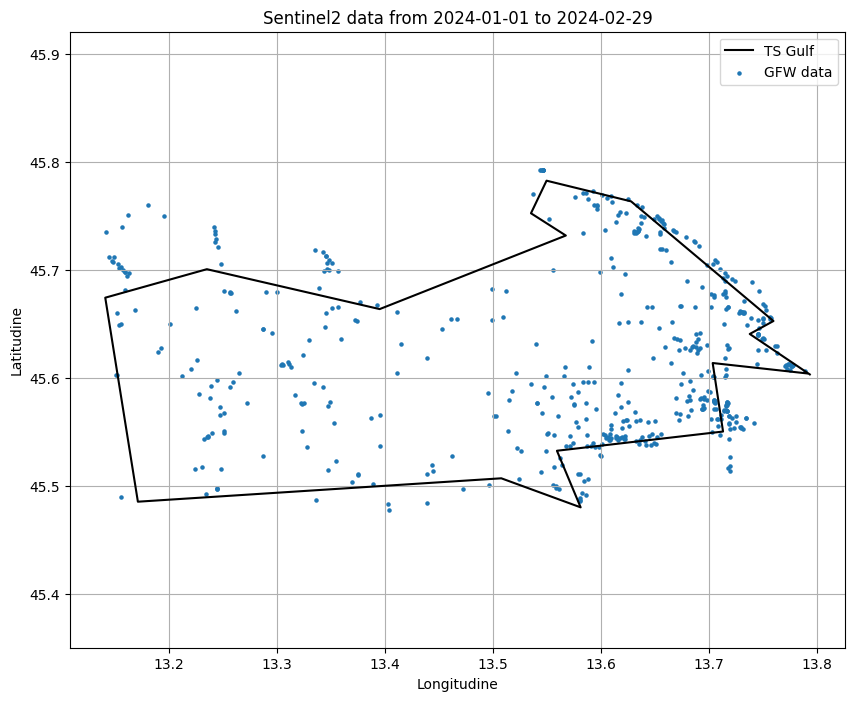

In [30]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(gfw_unq_coords[lon_name], gfw_unq_coords[lat_name], label = 'GFW data', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title(f"Sentinel2 data from {start_date} to {end_date}")

plt.show()

In [31]:
df.shape[0]

532